**Environment set-up**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Data Wranglign**

*In this section ,we would load our desired data from a flat csv file using pandas to further our data.*

In [2]:
#loading data and showing its first 5 lines
df=pd.read_csv("C:/Users/DELL/Downloads/tmdb-movies.csv")
df.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


**Data Cleaning**

*In this section ,we would dive deeper into exploring our dataset and perform cleaning
operations like (dropping columns,handling NaNs,converting data types).
All of which would help us reach a more accurate result in answering our inverstigating questions.*

In [3]:
#printing dataframe columns's info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  str    
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  str    
 6   cast                  10790 non-null  str    
 7   homepage              2936 non-null   str    
 8   director              10822 non-null  str    
 9   tagline               8042 non-null   str    
 10  keywords              9373 non-null   str    
 11  overview              10862 non-null  str    
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  str    
 14  production_companies  9836 non-null   str    
 15  release_date          10866 no

In [4]:
#taking a look at number of unique values
df.nunique()

id                      10865
imdb_id                 10855
popularity              10814
budget                    557
revenue                  4702
original_title          10571
cast                    10719
homepage                 2896
director                 5067
tagline                  7997
keywords                 8804
overview                10847
runtime                   247
genres                   2039
production_companies     7445
release_date             5909
vote_count               1289
vote_average               72
release_year               56
budget_adj               2614
revenue_adj              4840
dtype: int64

In [5]:
#closer look at the vote_average values
df['vote_average']

0        6.5
1        7.1
2        6.3
3        7.5
4        7.3
        ... 
10861    7.4
10862    5.7
10863    6.5
10864    5.4
10865    1.5
Name: vote_average, Length: 10866, dtype: float64

In [6]:
#calculating duplicated values
print(df.duplicated().sum())

1


**As we can see from the above output:**

1.Our dataset consists of a total of 10866 rows and 21 columns.

2.we have only 1 duplicated row which would be droped.

3.Some columns wont be useful in answering our question using analysis.

4.Few columns have many missing values that  needs to be handled.

5.Columns cast,director,genre have values saperated with a'|'.

6.release_date 's data type needs to be casted.

7.we can append a column for the movie profit using formula.

profit=revenue-budget.

8.vote_average better be presented as a catecorical variable that groubs multiple 
ratings values.
9.We may also catigorize profit column for better EDA.



**Start by dropping the duplicated row**

In [7]:
#dropping duplicares and valudating the excution
df.drop_duplicates(inplace=True)
df.duplicated().any()


np.False_

**check for data frame columns**

In [8]:
df.columns
df

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10861,21,tt0060371,0.080598,0,0,The Endless Summer,Michael Hynson|Robert August|Lord 'Tally Ho' B...,NaN,Bruce Brown,NaN,...,"The Endless Summer, by Bruce Brown, is one of ...",95,Documentary,Bruce Brown Films,6/15/66,11,7.4,1966,0.000000e+00,0.000000e+00
10862,20379,tt0060472,0.065543,0,0,Grand Prix,James Garner|Eva Marie Saint|Yves Montand|Tosh...,NaN,John Frankenheimer,Cinerama sweeps YOU into a drama of speed and ...,...,Grand Prix driver Pete Aron is fired by his te...,176,Action|Adventure|Drama,Cherokee Productions|Joel Productions|Douglas ...,12/21/66,20,5.7,1966,0.000000e+00,0.000000e+00
10863,39768,tt0060161,0.065141,0,0,Beregis Avtomobilya,Innokentiy Smoktunovskiy|Oleg Efremov|Georgi Z...,NaN,Eldar Ryazanov,NaN,...,An insurance agent who moonlights as a carthie...,94,Mystery|Comedy,Mosfilm,1/1/66,11,6.5,1966,0.000000e+00,0.000000e+00
10864,21449,tt0061177,0.064317,0,0,"What's Up, Tiger Lily?",Tatsuya Mihashi|Akiko Wakabayashi|Mie Hama|Joh...,NaN,Woody Allen,WOODY ALLEN STRIKES BACK!,...,"In comic Woody Allen's film debut, he took the...",80,Action|Comedy,Benedict Pictures Corp.,11/2/66,22,5.4,1966,0.000000e+00,0.000000e+00


*ater going through all the columns,we dicided that columns id,imdb_id,homepage,
revenue_adj,director,release_date will not be very usefull,so we will drop them and continue with our analysis.*

In [9]:
#dropping unuseful columns
df.drop(['id','imdb_id','homepage','revenue_adj','budget_adj','tagline',
         'cast','overview','keywords','production_companies','director','release_date'],axis=1,
        inplace=True)

In [10]:
df

,popularity,budget,revenue,original_title,runtime,genres,vote_count,vote_average,release_year
0,32.985763,150000000,1513528810,Jurassic World,124,Action|Adventure|Science Fiction|Thriller,5562,6.5,2015
1,28.419936,150000000,378436354,Mad Max: Fury Road,120,Action|Adventure|Science Fiction|Thriller,6185,7.1,2015
2,13.112507,110000000,295238201,Insurgent,119,Adventure|Science Fiction|Thriller,2480,6.3,2015
3,11.173104,200000000,2068178225,Star Wars: The Force Awakens,136,Action|Adventure|Science Fiction|Fantasy,5292,7.5,2015
4,9.335014,190000000,1506249360,Furious 7,137,Action|Crime|Thriller,2947,7.3,2015
...,...,...,...,...,...,...,...,...,...
10861,0.080598,0,0,The Endless Summer,95,Documentary,11,7.4,1966
10862,0.065543,0,0,Grand Prix,176,Action|Adventure|Drama,20,5.7,1966
10863,0.065141,0,0,Beregis Avtomobilya,94,Mystery|Comedy,11,6.5,1966
10864,0.064317,0,0,"What's Up, Tiger Lily?",80,Action|Comedy,22,5.4,1966


*check for data frame shape*

In [11]:
df.shape

(10865, 9)

**Now we only have 9 columns to start preprocessing on**

**check for null values**

In [12]:
df.isna().sum()

popularity         0
budget             0
revenue            0
original_title     0
runtime            0
genres            23
vote_count         0
vote_average       0
release_year       0
dtype: int64

**We can see that all of our columns are clean exept from the genre column.Since it is very 
important to answer our questions ,we would drop all its NaNs.**

In [13]:
df.dropna(inplace=True)

In [14]:
df.isna().sum()

popularity        0
budget            0
revenue           0
original_title    0
runtime           0
genres            0
vote_count        0
vote_average      0
release_year      0
dtype: int64

**Dealing with genres column's '|' saperated values**
*We would do our analysis with the first genre for each movie .we are going to take each 
hybrid row and extract the first genre (before the |)and save it to our datafram.*

In [15]:
#split values in the hybrid dataframe
df['genres']=df['genres'].apply(lambda x:x.split("|")[0])
df.head()

,popularity,budget,revenue,original_title,runtime,genres,vote_count,vote_average,release_year
0,32.985763,150000000,1513528810,Jurassic World,124,Action,5562,6.5,2015
1,28.419936,150000000,378436354,Mad Max: Fury Road,120,Action,6185,7.1,2015
2,13.112507,110000000,295238201,Insurgent,119,Adventure,2480,6.3,2015
3,11.173104,200000000,2068178225,Star Wars: The Force Awakens,136,Action,5292,7.5,2015
4,9.335014,190000000,1506249360,Furious 7,137,Action,2947,7.3,2015


**calculating movie  profit=revenue-budget**

In [16]:
#adding new column for movie profit(revenue-budget)
df['profit']=df['revenue']-df['budget']

**catigorizing vote_average profit_adj columns**

for usability and functionality sake,we would convert these columns using a function*

In [17]:
def catigorize_col(df,col,labels):
    edges=[df[col].describe()['min'],
           df[col].describe()['25%'],
           df[col].describe()['50%'],
           df[col].describe()['75%'],
           df[col].describe()['max']]
    df[col]=pd.cut(df[col],edges,labels=labels,duplicates='drop')
    return df
    
    

**Converting vote_average into a categorical variable**

We would cut the vote_average values and make 4 categories: popular, average ,below_avg ,not_popular to describe it more using catigorize_col() function provided above.

In [18]:
#define labels for these edges
labels=['not_popular','below_avg','average','popular']
catigorize_col(df,'vote_average',labels)

df['vote_average'].unique()

['average', 'popular', 'below_avg', 'not_popular', NaN]
Categories (4, str): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [19]:
df

,popularity,budget,revenue,original_title,runtime,genres,vote_count,vote_average,release_year,profit
0,32.985763,150000000,1513528810,Jurassic World,124,Action,5562,average,2015,1363528810
1,28.419936,150000000,378436354,Mad Max: Fury Road,120,Action,6185,popular,2015,228436354
2,13.112507,110000000,295238201,Insurgent,119,Adventure,2480,average,2015,185238201
3,11.173104,200000000,2068178225,Star Wars: The Force Awakens,136,Action,5292,popular,2015,1868178225
4,9.335014,190000000,1506249360,Furious 7,137,Action,2947,popular,2015,1316249360
...,...,...,...,...,...,...,...,...,...,...
10861,0.080598,0,0,The Endless Summer,95,Documentary,11,popular,1966,0
10862,0.065543,0,0,Grand Prix,176,Action,20,below_avg,1966,0
10863,0.065141,0,0,Beregis Avtomobilya,94,Mystery,11,average,1966,0
10864,0.064317,0,0,"What's Up, Tiger Lily?",80,Action,22,not_popular,1966,0


**We ended up with some NaNs ,so we would drop them**

In [20]:
df['vote_average'].isna().sum()

np.int64(2)

In [21]:
df.dropna(inplace=True)

In [22]:
df.isna().sum()

popularity        0
budget            0
revenue           0
original_title    0
runtime           0
genres            0
vote_count        0
vote_average      0
release_year      0
profit            0
dtype: int64

**Converting profit into a categorical variable**
we would cut the `profit ` values and make 3 categories :`high`,`average`,`low` to describe it more using `catigorize_col()` function provided above.

In [23]:
labels=['low','average','high']
catigorize_col(df,'profit',labels)

,popularity,budget,revenue,original_title,runtime,genres,vote_count,vote_average,release_year,profit
0,32.985763,150000000,1513528810,Jurassic World,124,Action,5562,average,2015,high
1,28.419936,150000000,378436354,Mad Max: Fury Road,120,Action,6185,popular,2015,high
2,13.112507,110000000,295238201,Insurgent,119,Adventure,2480,average,2015,high
3,11.173104,200000000,2068178225,Star Wars: The Force Awakens,136,Action,5292,popular,2015,high
4,9.335014,190000000,1506249360,Furious 7,137,Action,2947,popular,2015,high
...,...,...,...,...,...,...,...,...,...,...
10860,0.087034,0,0,Carry On Screaming!,87,Comedy,13,popular,1966,low
10861,0.080598,0,0,The Endless Summer,95,Documentary,11,popular,1966,low
10862,0.065543,0,0,Grand Prix,176,Action,20,below_avg,1966,low
10863,0.065141,0,0,Beregis Avtomobilya,94,Mystery,11,average,1966,low


In [25]:
df['profit'].unique()

['high', 'average', 'low', NaN]
Categories (3, str): ['low' < 'average' < 'high']

In [26]:
df.profit.isna().sum()

np.int64(1)

In [28]:
df.isna().sum()

popularity        0
budget            0
revenue           0
original_title    0
runtime           0
genres            0
vote_count        0
vote_average      0
release_year      0
profit            1
dtype: int64

In [29]:
df.dropna(inplace=True)


In [30]:
df.isna().sum()

popularity        0
budget            0
revenue           0
original_title    0
runtime           0
genres            0
vote_count        0
vote_average      0
release_year      0
profit            0
dtype: int64

In [31]:
df.head()

,popularity,budget,revenue,original_title,runtime,genres,vote_count,vote_average,release_year,profit
0,32.985763,150000000,1513528810,Jurassic World,124,Action,5562,average,2015,high
1,28.419936,150000000,378436354,Mad Max: Fury Road,120,Action,6185,popular,2015,high
2,13.112507,110000000,295238201,Insurgent,119,Adventure,2480,average,2015,high
3,11.173104,200000000,2068178225,Star Wars: The Force Awakens,136,Action,5292,popular,2015,high
4,9.335014,190000000,1506249360,Furious 7,137,Action,2947,popular,2015,high


In [32]:
df.info()

<class 'pandas.DataFrame'>
Index: 10839 entries, 0 to 10864
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   popularity      10839 non-null  float64 
 1   budget          10839 non-null  int64   
 2   revenue         10839 non-null  int64   
 3   original_title  10839 non-null  str     
 4   runtime         10839 non-null  int64   
 5   genres          10839 non-null  str     
 6   vote_count      10839 non-null  int64   
 7   vote_average    10839 non-null  category
 8   release_year    10839 non-null  int64   
 9   profit          10839 non-null  category
dtypes: category(2), float64(1), int64(5), str(2)
memory usage: 783.6 KB


**Now that we finished our data cleaning,our dataset consists of 10840 records with
10 columns,it has no duplicates nor null values ,and the data types are consistant
with suitable categorical variable to address our questions .we are ready to move to the 
next step!**

$EXPLORATORY DATA ANALYSIS$

* in this section ,we would use descibtive statistics and visuals to address
the following questions regarding our dataset

Q1.Do movies with high popularity achive high revenue

In [34]:
#get median of popularity to campare with 
df['popularity'].mean()

np.float64(0.6476021913460651)

In [36]:
#split popular movies into two groups around the median
less_popular=df.query('popularity<=0.647')
more_popular=df.query('popularity>0.647')


In [38]:
#get mean quality revenue for the less and more popularity groups 
print(less_popular.revenue.mean(),more_popular.revenue.mean())

7689823.871224779 121933819.08567691


From the above calculations, it's very clear that more popular movies recieve way more revenue than the less popular movies.
___

### Q2: What are the most filmed genres in this whole dataset?
___

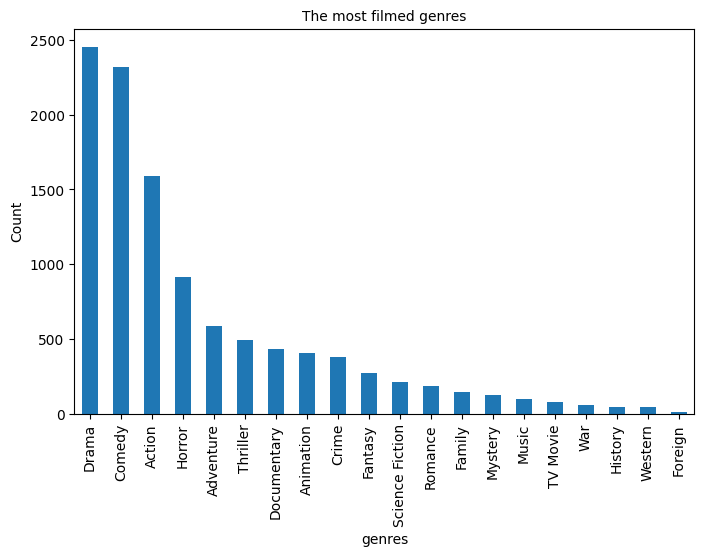

In [39]:
# visualising genres distribution
plt.figure(figsize=(8,5))
df['genres'].value_counts().plot(kind="bar")
plt.title("The most filmed genres", fontsize=(10))
plt.xlabel("genres", fontsize=10)
plt.ylabel("Count",fontsize=10)
plt.show()

In [49]:
df['genres'].describe()

count     10839
unique       20
top       Drama
freq       2453
Name: genres, dtype: object

from the above graph, we can see that `Drama`, `Comedy` and `Action` are the most three filmed genres in total of 10839 movies in our dataset, and that `Drama` genre is filmed 22.6% of the times on our dataset.
___

### Q3: Is there a correlation between a movie budget and its revenue?

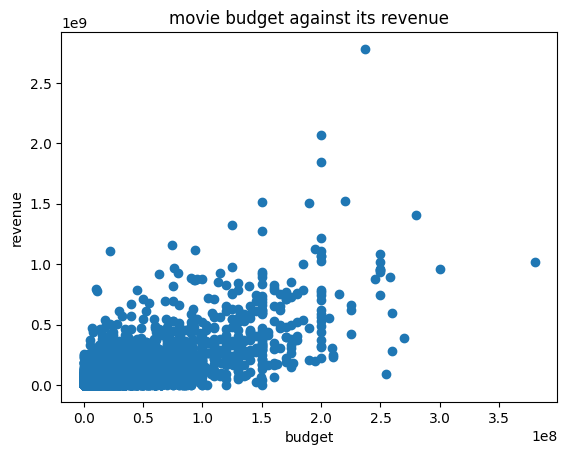

In [55]:
# plotting budget against revenue
plt.scatter(df['budget'],df['revenue']);
plt.title("movie budget against its revenue");
plt.xlabel('budget', fontsize=10);
plt.ylabel('revenue',fontsize=10);

We can notice the positive correlation between `budget` and `revenue`, indecating a relation between them with little outliers. 
___

<a id='conclusions'></a>

<a id='conclusions'></a>
## Conclusions

### Q1: Do movies with high popularity achive high revenvue?
> More popular movies recieve way more revenue than the less popular movies.
### Q2: What are the most filmed genres in this whole dataset?
> `Drama`, `Comedy` and `Action` are the most three filmed genres in total of 10839 movies in our dataset, and that `Drama` genre is filmed 22.6% of the times on our dataset.
### Q3: Is there a correlation between a movie budget and its revenue?
> There is positive correlation between `budget` and `revenue`, indecating a relation between them with little outliers. 
___
